# Naive Bayes Classification – Weather Dataset

**University AI/ML Laboratory**

### Objective
To implement the **Naive Bayes classification algorithm** for predicting whether it will rain based on weather conditions, using:
1. Manual calculation with **Bayes theorem**.
2. Scikit-learn's **CategoricalNB** for verification.

The dataset and test case are retained from the original lab notebook.

## Theory

Naive Bayes is a probabilistic classification algorithm based on Bayes theorem:

\[
P(C|X)=rac{P(X|C)P(C)}{P(X)}
\]

For multiple features, the Naive Bayes assumption treats the features as conditionally independent:

\[
P(C|X_1, X_2, ..., X_n) \propto P(C)\prod_i P(X_i|C)
\]

Here, all input features are **categorical**, so `CategoricalNB` is the appropriate scikit-learn variant.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Create the weather dataset from the original lab

data = {
    'Outlook': ['Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Sunny', 'Overcast',
                'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Overcast', 'Sunny'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['FALSE', 'TRUE', 'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE',
             'FALSE', 'FALSE', 'FALSE', 'TRUE', 'TRUE', 'FALSE', 'FALSE'],
    'Rain': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print(f"Dataset size: {df.shape[0]} rows × {df.shape[1]} columns")
df

Dataset size: 14 rows × 5 columns


,Outlook,Temp,Humidity,Wind,Rain
0,Rainy,Hot,High,FALSE,No
1,Rainy,Hot,High,TRUE,No
2,Overcast,Hot,High,FALSE,Yes
3,Sunny,Mild,High,FALSE,Yes
4,Sunny,Cool,Normal,FALSE,Yes
5,Sunny,Cool,Normal,TRUE,No
6,Overcast,Cool,Normal,TRUE,Yes
7,Rainy,Mild,High,FALSE,No
8,Rainy,Cool,Normal,FALSE,Yes
9,Sunny,Mild,Normal,FALSE,Yes


## 1. Define the test case

We will predict the class for:

**Outlook = Sunny, Temp = Hot, Humidity = Normal, Wind = FALSE**

In [3]:
# Test instance
features = ['Outlook', 'Temp', 'Humidity', 'Wind']
today = {'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'Normal', 'Wind': 'FALSE'}

today_df = pd.DataFrame([today])
print("Today's weather conditions:")
print(today_df.to_string(index=False))

Today's weather conditions:
Outlook Temp Humidity  Wind
  Sunny  Hot   Normal FALSE


## 2. Manual Naive Bayes calculation

First calculate the prior probabilities:

\[
P(Yes)=rac{9}{14},\qquad P(No)=rac{5}{14}
\]

Then calculate the conditional probabilities for each feature and class.

In [4]:
# Prior probabilities
class_counts = df['Rain'].value_counts()
total = len(df)
p_yes = class_counts['Yes'] / total
p_no = class_counts['No'] / total

print("PRIOR PROBABILITIES")
print(f"P(Rain=Yes) = {class_counts['Yes']}/{total} = {p_yes:.4f}")
print(f"P(Rain=No)  = {class_counts['No']}/{total} = {p_no:.4f}")

PRIOR PROBABILITIES
P(Rain=Yes) = 9/14 = 0.6429
P(Rain=No)  = 5/14 = 0.3571


In [5]:
# Conditional probability helper

def conditional_probability(feature, value, target):
    class_rows = df[df['Rain'] == target]
    count = (class_rows[feature] == value).sum()
    probability = count / len(class_rows)
    return count, len(class_rows), probability

# Calculate conditional probabilities for today's features
conditional = {}
for target in ['Yes', 'No']:
    conditional[target] = {}
    print(f"\nFor Rain = {target}:")
    for feature in features:
        count, denominator, probability = conditional_probability(
            feature, today[feature], target
        )
        conditional[target][feature] = probability
        print(f"P({today[feature]} | {target}) = {count}/{denominator} = {probability:.4f}")


For Rain = Yes:
P(Sunny | Yes) = 3/9 = 0.3333
P(Hot | Yes) = 2/9 = 0.2222
P(Normal | Yes) = 6/9 = 0.6667
P(FALSE | Yes) = 6/9 = 0.6667

For Rain = No:
P(Sunny | No) = 2/5 = 0.4000
P(Hot | No) = 2/5 = 0.4000
P(Normal | No) = 1/5 = 0.2000
P(FALSE | No) = 3/5 = 0.6000


In [6]:
# Apply Naive Bayes formula
likelihood_yes = 1
likelihood_no = 1

for feature in features:
    likelihood_yes *= conditional['Yes'][feature]
    likelihood_no *= conditional['No'][feature]

joint_yes = p_yes * likelihood_yes
joint_no = p_no * likelihood_no

p_features = joint_yes + joint_no
posterior_yes = joint_yes / p_features
posterior_no = joint_no / p_features

print("BAYES THEOREM CALCULATION")
print(f"P(Yes ∩ Features) = {joint_yes:.6f}")
print(f"P(No  ∩ Features) = {joint_no:.6f}")
print(f"P(Features)       = {p_features:.6f}")
print(f"P(Yes | Features) = {posterior_yes:.4f} ({posterior_yes:.2%})")
print(f"P(No  | Features) = {posterior_no:.4f} ({posterior_no:.2%})")

BAYES THEOREM CALCULATION
P(Yes ∩ Features) = 0.021164
P(No  ∩ Features) = 0.006857
P(Features)       = 0.028021
P(Yes | Features) = 0.7553 (75.53%)
P(No  | Features) = 0.2447 (24.47%)


In [7]:
# Manual prediction
manual_prediction = 'Yes' if posterior_yes > posterior_no else 'No'

print("MANUAL PREDICTION")
print(f"Predicted class: {manual_prediction}")
print(f"Confidence: {max(posterior_yes, posterior_no):.2%}")

MANUAL PREDICTION
Predicted class: Yes
Confidence: 75.53%


## 3. Naive Bayes using Scikit-learn

Because the weather attributes are categorical, we use `CategoricalNB` rather than `GaussianNB`.

`OrdinalEncoder` converts the categories into integer codes only for the model input; the values are treated as categorical categories, not as continuous measurements.

In [8]:
# Encode categorical features for CategoricalNB
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X = encoder.fit_transform(df[features]).astype(int)
y = df['Rain']

today_encoded = encoder.transform(today_df[features]).astype(int)

print("Encoded feature data:")
print(X[:5])
print("\nEncoded test instance:")
print(today_encoded)

Encoded feature data:
[[1 1 0 0]
 [1 1 0 1]
 [0 1 0 0]
 [2 2 0 0]
 [2 0 1 0]]

Encoded test instance:
[[2 1 1 0]]


In [9]:
# Train Categorical Naive Bayes model
model = CategoricalNB()
model.fit(X, y)

# Predict today's weather
sklearn_prediction = model.predict(today_encoded)[0]
sklearn_probabilities = model.predict_proba(today_encoded)[0]

print("SCIKIT-LEARN PREDICTION")
print(f"Predicted class: {sklearn_prediction}")
for class_name, probability in zip(model.classes_, sklearn_probabilities):
    print(f"P(Rain={class_name} | Features) = {probability:.2%}")

SCIKIT-LEARN PREDICTION
Predicted class: Yes
P(Rain=No | Features) = 27.43%
P(Rain=Yes | Features) = 72.57%


In [10]:
# Training-set evaluation for demonstration
train_pred = model.predict(X)
accuracy = accuracy_score(y, train_pred)
cm = confusion_matrix(y, train_pred, labels=['No', 'Yes'])

print("MODEL EVALUATION")
print(f"Training accuracy: {accuracy:.2%}")
print("\nConfusion matrix [No, Yes]:")
print(cm)
print("\nClassification report:")
print(classification_report(y, train_pred, zero_division=0))

MODEL EVALUATION
Training accuracy: 85.71%

Confusion matrix [No, Yes]:
[[3 2]
 [0 9]]

Classification report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.82      1.00      0.90         9

    accuracy                           0.86        14
   macro avg       0.91      0.80      0.82        14
weighted avg       0.88      0.86      0.85        14



## 4. Posterior probability comparison

In [11]:
# Compare manual and scikit-learn posterior probabilities
comparison = pd.DataFrame({
    'Class': ['Rain = Yes', 'Rain = No'],
    'Manual Bayes': [posterior_yes, posterior_no],
    'CategoricalNB': [sklearn_probabilities[list(model.classes_).index('Yes')],
                      sklearn_probabilities[list(model.classes_).index('No')]]
})

comparison

,Class,Manual Bayes,CategoricalNB
0,Rain = Yes,0.755287,0.725707
1,Rain = No,0.244713,0.274293


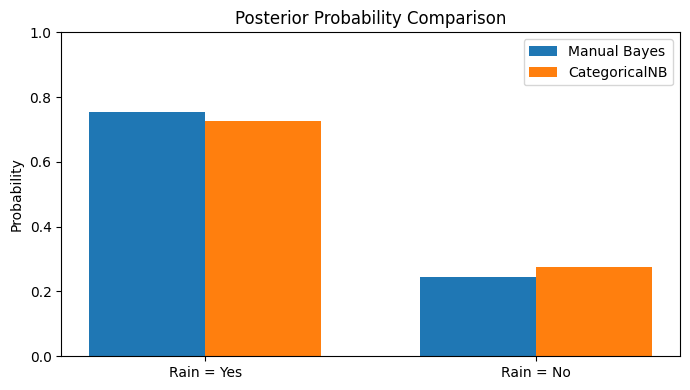

In [12]:
# Visualize posterior probabilities
plt.figure(figsize=(7, 4))
x = range(len(comparison))
width = 0.35
plt.bar([i - width/2 for i in x], comparison['Manual Bayes'], width, label='Manual Bayes')
plt.bar([i + width/2 for i in x], comparison['CategoricalNB'], width, label='CategoricalNB')
plt.xticks(list(x), comparison['Class'])
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.title('Posterior Probability Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Result and Conclusion

For the test condition **(Sunny, Hot, Normal, FALSE)**, the manual Naive Bayes calculation predicts the class with the larger posterior probability. The same prediction is obtained using scikit-learn's `CategoricalNB`.

### Conclusion
Naive Bayes can be used to classify categorical weather data by calculating prior probabilities, conditional probabilities, and posterior probabilities. The manual implementation demonstrates the underlying Bayes theorem, while `CategoricalNB` provides a concise machine-learning implementation.

## Viva Points

- **Why Naive Bayes?** It is simple, fast, and based on probability.
- **Why is it called “Naive”?** It assumes conditional independence between features given the class.
- **Why `CategoricalNB`?** The weather attributes are categorical.
- **Why not `GaussianNB` here?** GaussianNB assumes continuous features following Gaussian distributions.
- **What is the prior?** The probability of a class before considering the features.
- **What is the posterior?** The probability of a class after considering the observed features.